<a href="https://colab.research.google.com/github/chihway/mapping_the_universe/blob/main/Basic/Tutorial%203%20-%20Galaxy%20Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 3 - Galaxy Images

In this tutorial we will learn how to open and manipulate a galaxy image in the FITS format and make some simple plots. In this tutorial you will be able to

* read and understand the fits images
* display the image and adjust basic parameters of the image
* make some plots based on the pixel values

If you already know all of this, feel free to skip to [Tutorial 4 - Maps](https://github.com/chihway/mapping_the_universe/blob/main/Basic/Tutorial%204%20-%20Maps.ipynb).


The images that we will be using are the DES deep field coadd images (the images that correspond to the catalogs in the previous tutorial). These images are target effective exposure times 10x the average integrated per pixel exposure time in the main DES survey. You can read about them in [Hartley & Choi et al. (2021)](https://arxiv.org/abs/2012.12824) and the details of the images can be found on the [DES data release page](https://des.ncsa.illinois.edu/releases/y3a2/Y3deepfields).

In [7]:
import astropy
import astropy.io.fits as pf
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [8]:
# We will download a specific CCD chip in the COSMOS field, we will download all the bands (ugrizY)
# "C" refers to the CCD chip, the number after "C", "15" in this case, is the number that identifies
# which CCD chip on the focal plane it is. The geometry of the DES focalplane can be found here: 
# https://noirlab.edu/science/images/decamorientation-0 
# (the green numbers in the plot is what we are using here, so our chip is close to the center of the 
# focal plane)

!curl -O https://desdr-server.ncsa.illinois.edu/despublic/y3a2_files/deepfields/COADD_TRUTH/COSMOS/COSMOS_C15_COADD_TRUTH_u.fits.fz
!curl -O https://desdr-server.ncsa.illinois.edu/despublic/y3a2_files/deepfields/COADD_TRUTH/COSMOS/COSMOS_C15_COADD_TRUTH_g.fits.fz
!curl -O https://desdr-server.ncsa.illinois.edu/despublic/y3a2_files/deepfields/COADD_TRUTH/COSMOS/COSMOS_C15_COADD_TRUTH_r.fits.fz
!curl -O https://desdr-server.ncsa.illinois.edu/despublic/y3a2_files/deepfields/COADD_TRUTH/COSMOS/COSMOS_C15_COADD_TRUTH_i.fits.fz
!curl -O https://desdr-server.ncsa.illinois.edu/despublic/y3a2_files/deepfields/COADD_TRUTH/COSMOS/COSMOS_C15_COADD_TRUTH_z.fits.fz
!curl -O https://desdr-server.ncsa.illinois.edu/despublic/y3a2_files/deepfields/COADD_TRUTH/COSMOS/COSMOS_C15_COADD_TRUTH_Y.fits.fz
    

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 16.6M  100 16.6M    0     0  4171k      0  0:00:04  0:00:04 --:--:-- 4172k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 16.5M  100 16.5M    0     0  5202k      0  0:00:03  0:00:03 --:--:-- 5202k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 16.5M  100 16.5M    0     0  5393k      0  0:00:03  0:00:03 --:--:-- 5393k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 17.0M  100 17.0M    0     0  5783k      0  0:00:03  0:00:03 --:--:-- 5783k   0  0:00:03  0:00:01  0:00:02 4674k
  % Total    % 

In [9]:
# Let's spend some time on the r band image

image = pf.open('COSMOS_C15_COADD_TRUTH_r.fits.fz')

In [10]:
# Take a quick look at the structure of the fits file
# note that it is quite different from the fits table we looked at in the previous tutorial

image.info()

Filename: COSMOS_C15_COADD_TRUTH_r.fits.fz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   ()      
  1  SCI           1 CompImageHDU     82   (4200, 2200)   float32   
  2  MSK           1 CompImageHDU     74   (4200, 2200)   int32   
  3  WGT           1 CompImageHDU     64   (4200, 2200)   float32   


* The 0th extension, similar to the previous tutorial, does not do anything.
* The 1st extension is the science image
* The 2nd extension is the mask
* The 3rd extension is the weight

All images have dimension 4200 x 2200 pixels$^2$. We commonly call these CCD chips 4k by 2k. Each pixel is 0.2637 arcsec in the center of the field, making the chips 18.46 x 9.67 arcmin$^2$.

Text(0.5, 1.0, 'Weight')

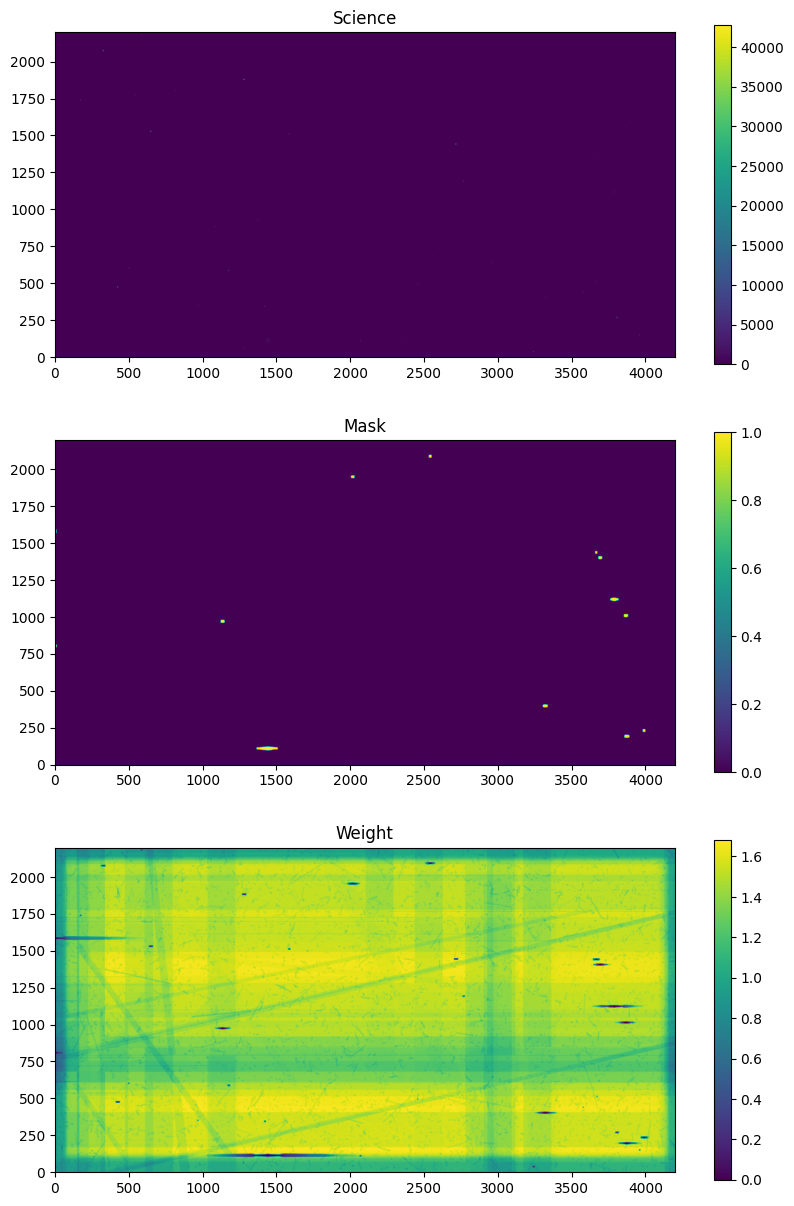

In [20]:
# Let's take a look at the images
plt.figure(figsize=(10,15))
plt.subplot(311)
plt.imshow(image[1].data, origin='lower')
plt.colorbar()
plt.title('Science')
plt.subplot(312)
plt.imshow(image[2].data, origin='lower')
plt.colorbar()
plt.title('Mask')
plt.subplot(313)
plt.imshow(image[3].data, origin='lower')
plt.colorbar()
plt.title('Weight')

# If we just plot it on itself it's hard to see anything, this is because the dynamical range is v large
# for the first image, we can make a histogram to see


Text(0.5, 0, 'pixel value')

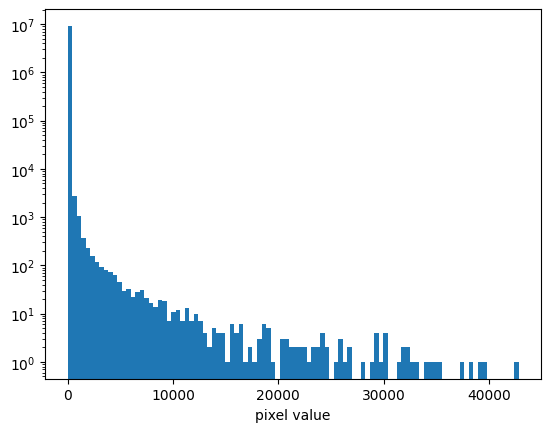

In [53]:
plt.hist(image[1].data.flatten(), bins=100)
plt.yscale('log')
plt.xlabel('pixel value')

# most of the pixels are zeros!

16.38422389984131 38.895352249145404


Text(0.5, 1.0, 'Weight')

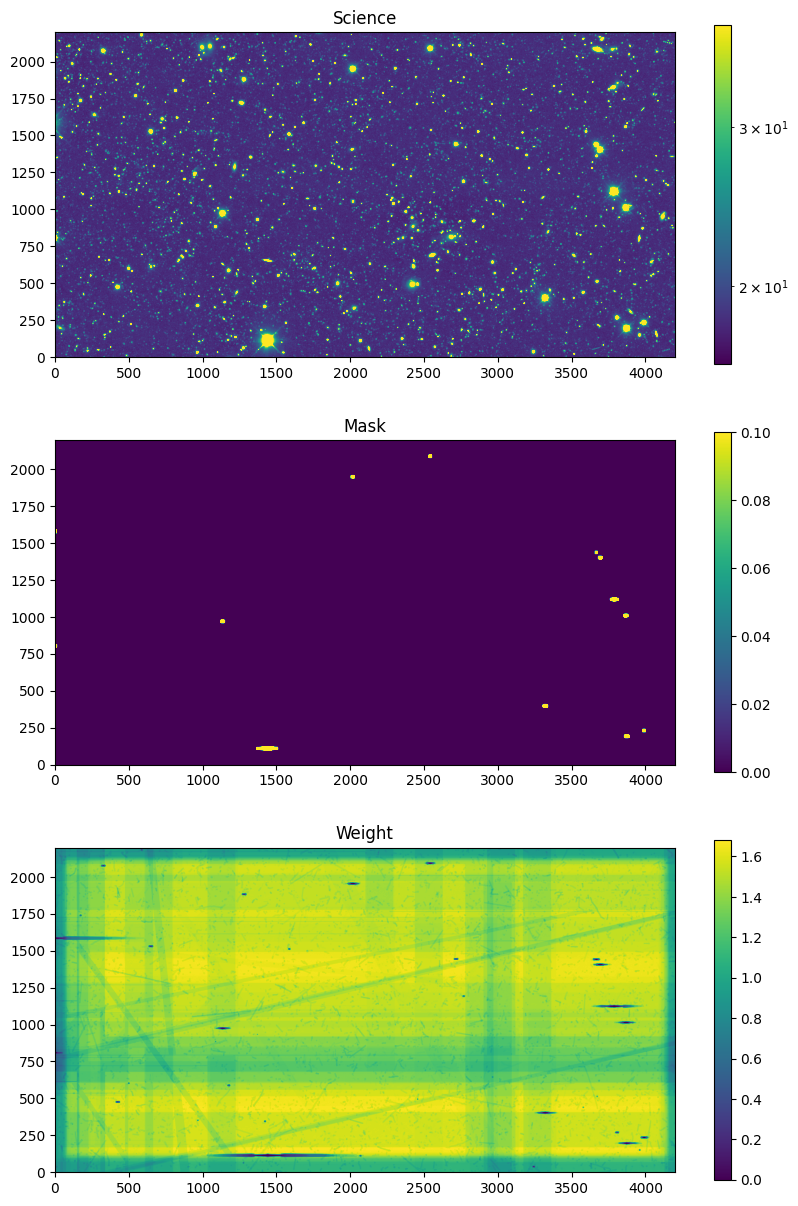

In [59]:
plt.figure(figsize=(10,15))
from matplotlib.colors import LogNorm

plt.subplot(311)

# Make all pixel values positive
data = image[1].data - np.min(image[1].data)

# Set a normalization method for high dynamic range (LogNorm)
vmin = np.percentile(data, 1)  # Lower percentile for minimum value
vmax = np.percentile(data, 99)  # Upper percentile for maximum value
print(vmin, vmax)
plt.imshow(data, origin='lower', norm=LogNorm(vmin=vmin, vmax=vmax))
plt.colorbar()
plt.title('Science')

plt.subplot(312)
plt.imshow(image[2].data, origin='lower')
plt.colorbar()

# make it clear which pixels is not zero -- we are masking saturated pixels for the most part
plt.clim(0,0.1)
plt.title('Mask')

# you can see where the masks are non-zero there is typically also some downweighting
plt.subplot(313)
plt.imshow(image[3].data, origin='lower')
plt.colorbar()
plt.title('Weight')


2.601788640022278 108.51305496215824


Text(0.5, 1.0, 'Weight')

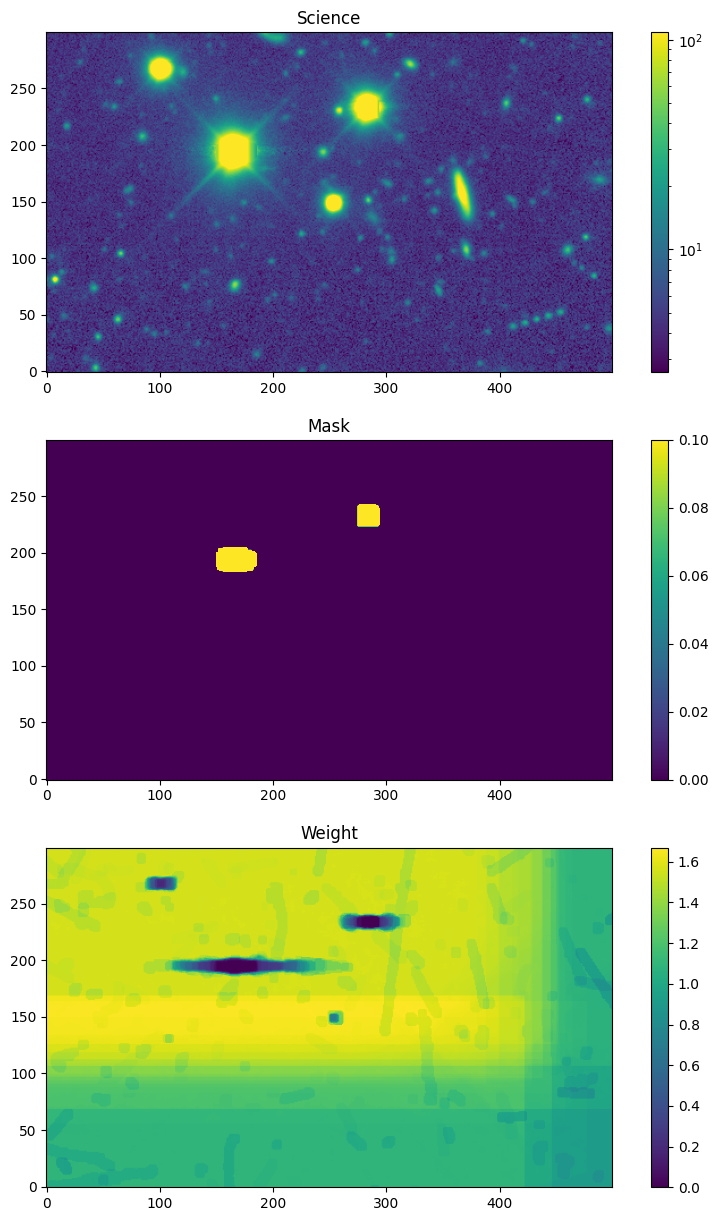

In [63]:
# Lets zoom into one of the interesting regions

plt.figure(figsize=(10,15))

subimage = image[1].data[:300, 3700:]
submask = image[2].data[:300, 3700:]
subweight = image[3].data[:300, 3700:]

plt.subplot(311)

# Make all pixel values positive
data = subimage - np.min(subimage)

# Set a normalization method for high dynamic range (LogNorm)
vmin = np.percentile(data, 1)  # Lower percentile for minimum value
vmax = np.percentile(data, 99)  # Upper percentile for maximum value
print(vmin, vmax)
plt.imshow(data, origin='lower', norm=LogNorm(vmin=vmin, vmax=vmax))
plt.colorbar()
plt.title('Science')

plt.subplot(312)
plt.imshow(submask, origin='lower')
plt.colorbar()
plt.clim(0,0.1)
plt.title('Mask')

plt.subplot(313)
plt.imshow(subweight, origin='lower')
plt.colorbar()
plt.title('Weight')


You can see that there are a lot of interesting things in the images when you zoom in! including (I think) a moving object on the lower right corner. 

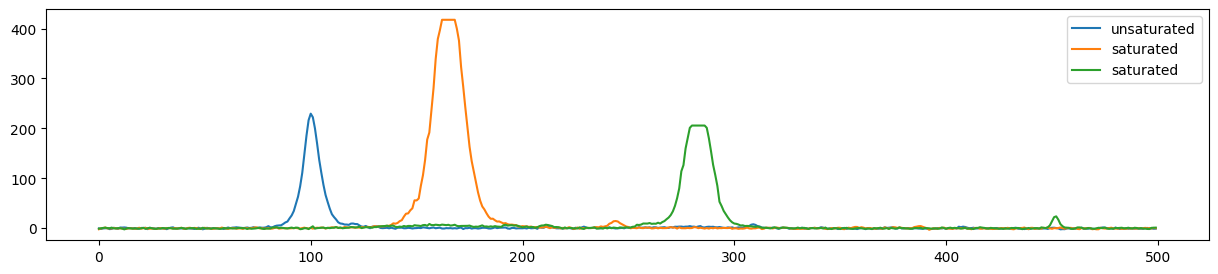

In [75]:
# plot the pixel values across saturated and unsaturated objects
plt.figure(figsize=(15,3))
plt.plot(subimage[260], label='unsaturated')
plt.plot(subimage[190], label='saturated')
plt.plot(subimage[225], label='saturated')
plt.legend()

In [78]:
# Let's now look at all the 6 bands together

Image = []
Band = ['u', 'g', 'r', 'i', 'z', 'Y']

for band in Band:
    image = pf.open('COSMOS_C15_COADD_TRUTH_'+str(band)+'.fits.fz')
    Image.append(image)

2.465312485694885 31.563649845123486
1.3365911412239075 88.07061897278051
16.34202875137329 122.25329696655277
36.098210372924804 178.36860412597701
41.810957984924315 240.97315795898453
17.638463344573974 312.46155944824454


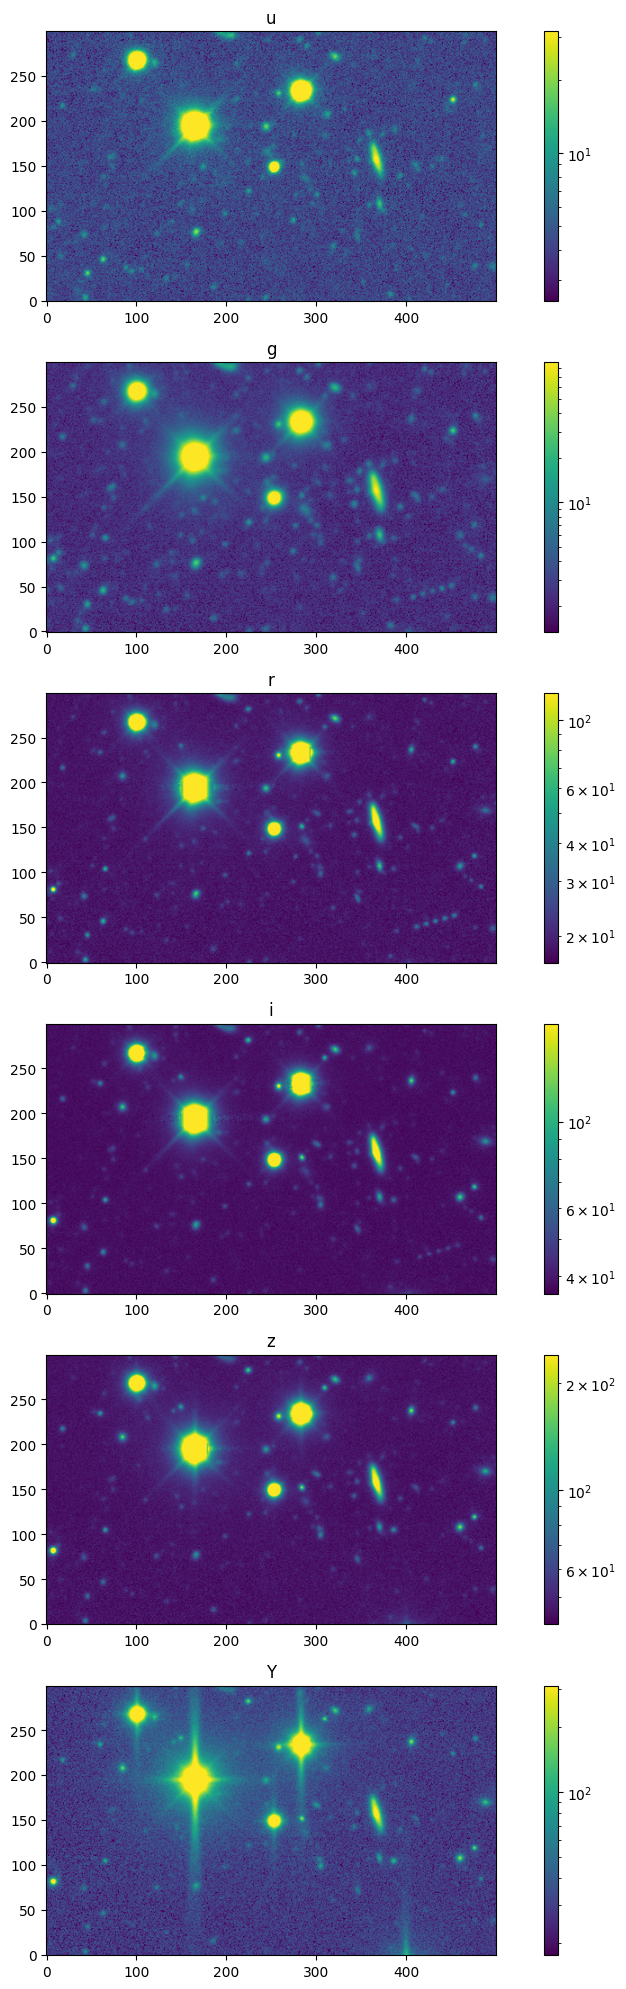

In [81]:
plt.figure(figsize=(10,20))
from matplotlib.colors import LogNorm

for i in range(6):
    plt.subplot(6,1,i+1)

    # Make all pixel values positive
    data = Image[i][1].data - np.min(Image[i][1].data)
    data = data[:300, 3700:]

    # Set a normalization method for high dynamic range (LogNorm)
    vmin = np.percentile(data, 1)  # Lower percentile for minimum value
    vmax = np.percentile(data, 99)  # Upper percentile for maximum value
    print(vmin, vmax)
    plt.imshow(data, origin='lower', norm=LogNorm(vmin=vmin, vmax=vmax))
    plt.colorbar()
    plt.title(Band[i])

plt.tight_layout()

# we see that each band has quite different dynamical ranges, which 
# corresponds to the different noise level and signal-to-noise
# some objects don't show up in some bands but show up with others